In [ ]:
import geopandas as gpd
from pathlib import Path
import os
import numpy as np
from pyproj import Transformer
import requests
import time

In [68]:
REPO_ROOT = Path(os.getcwd()).parent
DATA_PATH  = REPO_ROOT / "data" / "backtest" / "hist_data.parquet"

<Axes: ylabel='Frequency'>

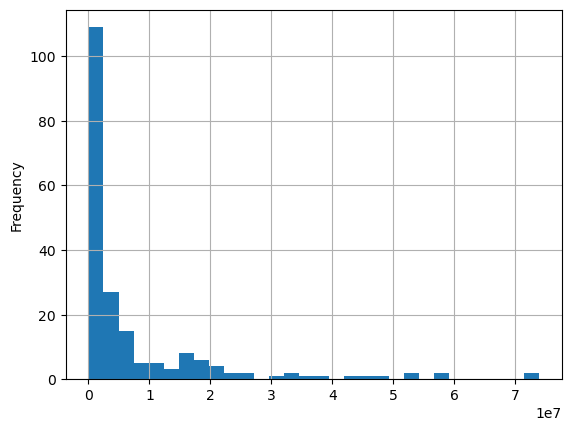

In [72]:
gdf = gpd.read_parquet(DATA_PATH)

gdf_metric = gdf.to_crs(epsg=2154)

areas = gdf_metric.geometry.area

areas.plot.hist(bins= 30, grid = True)

In [138]:
area_data = (gdf.assign(polygon_area = gdf.geometry.area)[["wildfire_id", "prop_step","polygon_area"]]
            .set_index(["wildfire_id", "prop_step"]))

gdf = gdf.merge(area_data, how = 'left', on = ["wildfire_id", "prop_step"])

In [144]:
gdf[["wildfire_id", 'prop_step', 'polygon_area']].query("wildfire_id == 45")

,wildfire_id,prop_step,polygon_area
170,45,0,3.136548e+00
171,45,1,5.548240e+06
172,45,2,1.873395e+07
173,45,3,3.326883e+07
174,45,4,3.605958e+07
175,45,5,4.342728e+07
176,45,6,5.850543e+07


In [125]:
gdf["wildfire_id"].value_counts()

wildfire_id
1     7
45    7
6     6
20    5
4     5
7     5
10    5
12    5
17    5
30    5
35    5
44    5
3     4
16    4
15    4
18    4
25    4
26    4
27    4
28    4
31    4
34    4
37    4
41    4
42    4
50    4
51    4
2     3
5     3
8     3
9     3
11    3
13    3
14    3
19    3
21    3
22    3
23    3
24    3
29    3
32    3
33    3
36    3
38    3
39    3
40    3
43    3
46    3
47    3
48    3
49    3
52    3
Name: count, dtype: int64

In [147]:
gdf.columns

Index(['wildfire_id', 'prop_step', 'date', 'country', 'province', 'commune',
       'quality', 'clouds', 'smoke', 'firedate', 'finaldate', 'crop',
       'crop/veg', 'tree-broad', 'tree-needl', 'tree-mixed', 'veg-mixed',
       'shrub', 'sparse_veg', 'urban', 'bare', 'grassland', 'geometry',
       'polygon_area'],
      dtype='str')

In [75]:
%cd ..
from simulators.backtest import FireForestViz


/home/perann/Bureau/MVA/Interactions/interactions


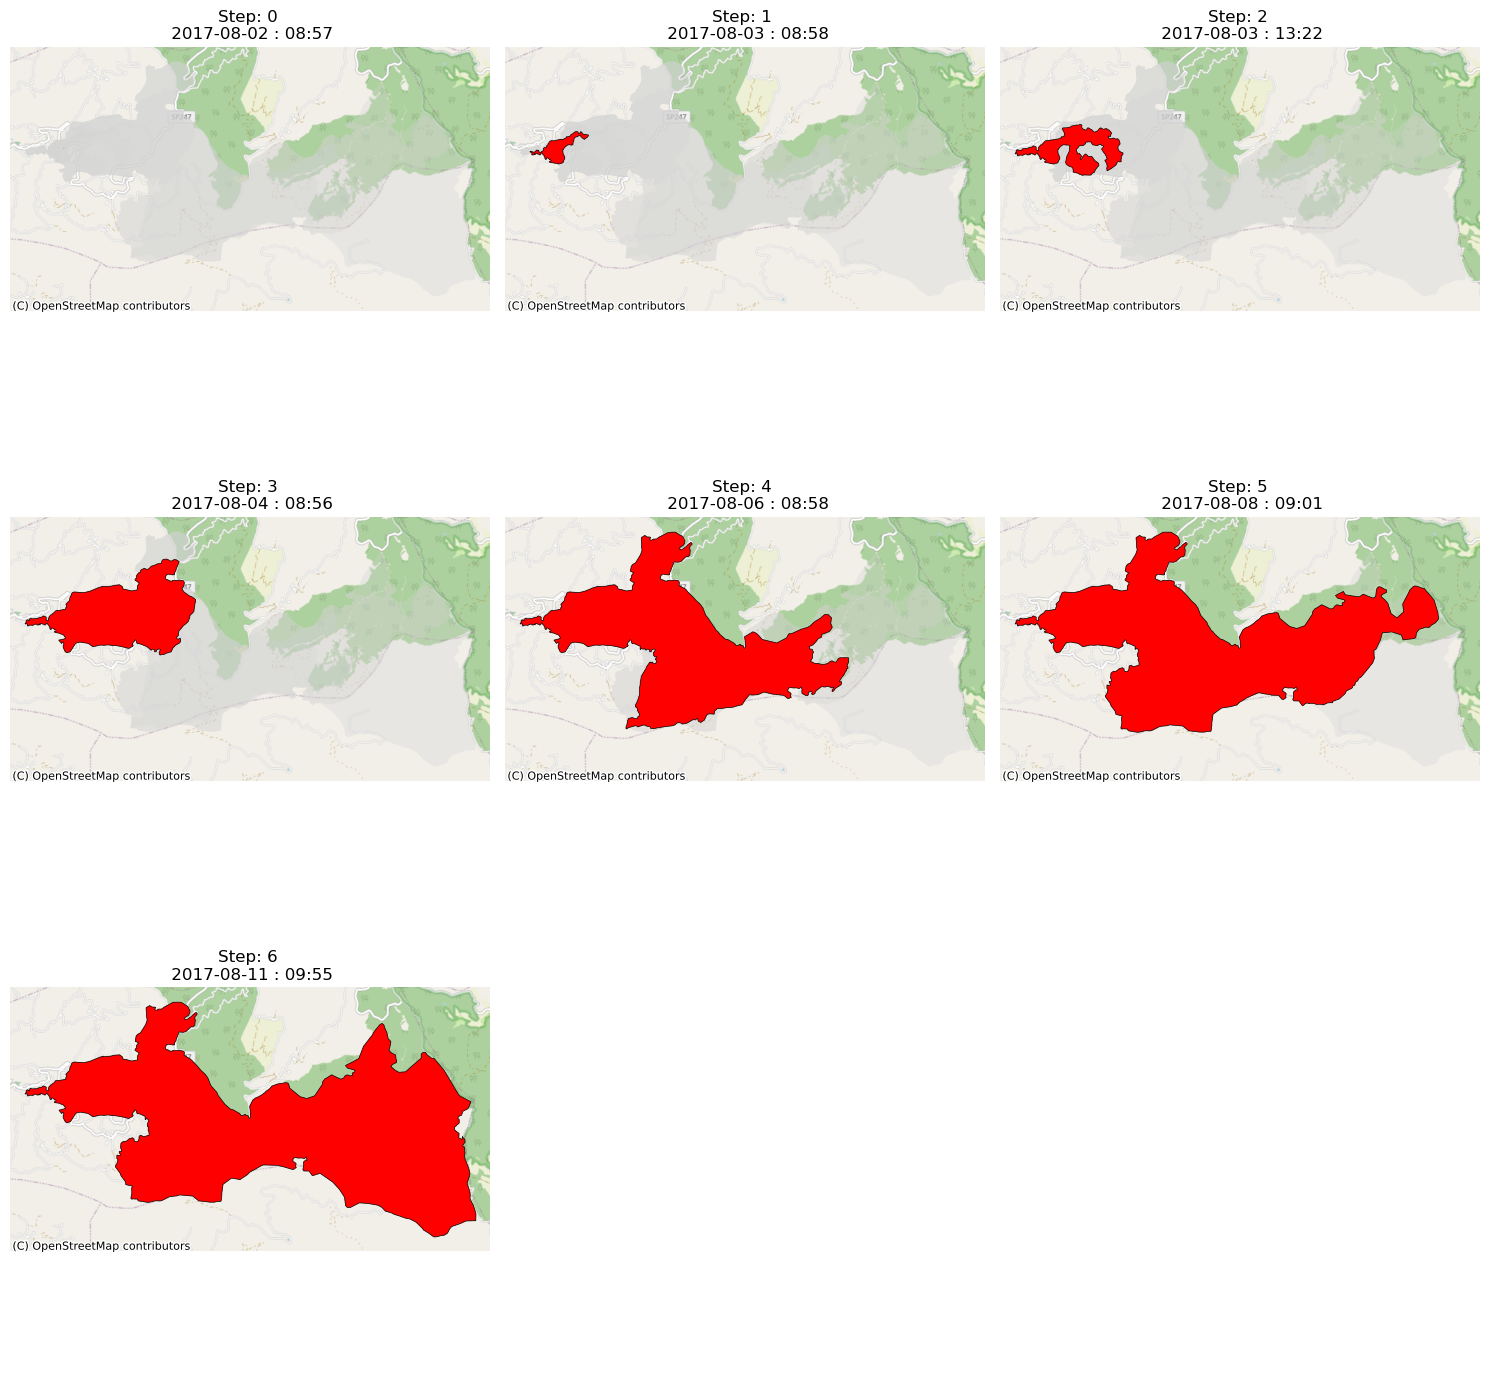

In [ ]:
FireForestViz(1)

In [ ]:
margin = 400
minx = gdf[gdf.wildfire_id == 1].total_bounds[0] - margin
miny = gdf[gdf.wildfire_id == 1].total_bounds[1] - margin
maxx = gdf[gdf.wildfire_id == 1].total_bounds[2] + margin
maxy = gdf[gdf.wildfire_id == 1].total_bounds[3] + margin


res = 200

width = int((maxx - minx) / res)
height = int((maxy - miny) / res)

altitude = np.zeros((height, width))

x_centers = minx + (np.arange(width) * res) + (res / 2)
y_centers = miny + (np.arange(height) * res) + (res / 2)

grid_x, grid_y = np.meshgrid(x_centers, y_centers)

transformer = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)
lon_flat, lat_flat = transformer.transform(grid_x.flatten(), grid_y.flatten())


In [ ]:

def get_elevation_grid(lat_flat, lon_flat, height, width):
    elevations = []
    chunk_size = 50  # On envoie un gros paquet pour limiter le nombre de requêtes
    i = 0
    
    print(f"Début de la récupération : {len(lat_flat)} points à traiter.")

    while i < len(lat_flat):
        # Sélection du paquet de points
        lats_chunk = lat_flat[i : i + chunk_size]
        lons_chunk = lon_flat[i : i + chunk_size]
        
        lats_str = ",".join([f"{l:.5f}" for l in lats_chunk])
        lons_str = ",".join([f"{l:.5f}" for l in lons_chunk])
        
        url = f"https://api.open-meteo.com/v1/elevation?latitude={lats_str}&longitude={lons_str}"
        
        try:
            response = requests.get(url)
            data = response.json()
            
            if response.status_code == 200:
                # Succès ! On stocke et on avance l'index i
                elevations.extend(data['elevation'])
                print(f"Succès : {len(elevations)}/{len(lat_flat)} points récupérés.")
                i += chunk_size
                time.sleep(1) # Petite pause de courtoisie
                
            elif response.status_code == 429 or (data.get('error') and 'limit exceeded' in data.get('reason', '')):
                # Limite atteinte : on attend et on ne touche pas à 'i' pour recommencer le même bloc
                print(f"\n[!] Limite API atteinte au point {i}. Pause de 62 secondes...")
                time.sleep(62) 
            else:
                print(f"Erreur API inattendue : {data.get('reason')}")
                break
                
        except Exception as e:
            print(f"Erreur de connexion : {e}. Nouvelle tentative dans 5 secondes...")
            time.sleep(5)

    # Reconstruction de la matrice
    if len(elevations) >= len(lat_flat):
        # On s'assure d'avoir la taille exacte (au cas où le dernier chunk dépasse)
        final_elev = np.array(elevations[:len(lat_flat)]).reshape((height, width))
        # On inverse le sens pour que le haut de la matrice soit le Nord
        return np.flipud(final_elev)
    else:
        return None

# Utilisation
matrix_elevation = get_elevation_grid(lat_flat, lon_flat, height, width)

Début de la récupération : 5460 points à traiter.
Erreur de connexion : Expecting value: line 1 column 1 (char 0). Nouvelle tentative dans 5 secondes...


KeyboardInterrupt: 

In [192]:
def get_weather_grid(lat_flat, lon_flat, height, width, date_str, hour_idx=14):
    temps = []
    wind_speeds = []
    wind_dirs = []
    chunk_size = 50 
    i = 0
    
    print(f"Récupération météo pour le {date_str} à {hour_idx}h...")

    while i < len(lat_flat):
        lats_chunk = lat_flat[i : i + chunk_size]
        lons_chunk = lon_flat[i : i + chunk_size]
        
        lats_str = ",".join([f"{l:.5f}" for l in lats_chunk])
        lons_str = ",".join([f"{l:.5f}" for l in lons_chunk])
        
        # URL de l'archive météo
        url = (f"https://archive-api.open-meteo.com/v1/archive?"
               f"latitude={lats_str}&longitude={lons_str}&"
               f"start_date={date_str}&end_date={date_str}&"
               f"hourly=temperature_2m,wind_speed_10m,wind_direction_10m&"
               f"timezone=auto")
        
        try:
            response = requests.get(url)
            data = response.json()
            
            if response.status_code == 200:
                # data est une LISTE de dictionnaires (un par point)
                for point_data in data:
                    # On récupère la valeur à l'heure précise (hour_idx)
                    temps.append(point_data['hourly']['temperature_2m'][hour_idx])
                    wind_speeds.append(point_data['hourly']['wind_speed_10m'][hour_idx])
                    wind_dirs.append(point_data['hourly']['wind_direction_10m'][hour_idx])
                
                i += chunk_size
                print(f"Météo : {len(temps)}/{len(lat_flat)} points.")
                time.sleep(0.5)
                
            elif response.status_code == 429:
                print("Limite API. Pause 62s...")
                time.sleep(62)
            else:
                print(f"Erreur : {data.get('reason')}")
                break
        except Exception as e:
            print(f"Erreur connexion : {e}")
            time.sleep(5)

    res_temps = np.flipud(np.array(temps).reshape((height, width)))
    res_wind_speed = np.flipud(np.array(wind_speeds).reshape((height, width)))
    res_wind_dir = np.flipud(np.array(wind_dirs).reshape((height, width)))
    
    return res_temps, res_wind_speed, res_wind_dir

m_temp, m_wind_v, m_wind_d = get_weather_grid(lat_flat, lon_flat, height, width, "2023-08-15", 14)

Récupération météo pour le 2023-08-15 à 14h...
Météo : 50/5460 points.
Météo : 100/5460 points.
Météo : 150/5460 points.
Météo : 200/5460 points.
Météo : 250/5460 points.
Météo : 300/5460 points.
Météo : 350/5460 points.
Météo : 400/5460 points.
Limite API. Pause 62s...
Météo : 450/5460 points.
Météo : 500/5460 points.
Météo : 550/5460 points.
Météo : 600/5460 points.
Météo : 650/5460 points.
Météo : 700/5460 points.
Météo : 750/5460 points.
Météo : 800/5460 points.
Météo : 850/5460 points.
Météo : 900/5460 points.
Météo : 950/5460 points.
Météo : 1000/5460 points.
Limite API. Pause 62s...
Météo : 1050/5460 points.
Météo : 1100/5460 points.
Météo : 1150/5460 points.
Météo : 1200/5460 points.
Météo : 1250/5460 points.
Météo : 1300/5460 points.
Météo : 1350/5460 points.
Météo : 1400/5460 points.
Météo : 1450/5460 points.
Météo : 1500/5460 points.
Météo : 1550/5460 points.
Météo : 1600/5460 points.
Limite API. Pause 62s...
Météo : 1650/5460 points.
Météo : 1700/5460 points.
Météo : 1750/5

KeyboardInterrupt: 